In [1]:
import numpy as np
from netCDF4 import Dataset
import matplotlib.pyplot as plt
#import cartopy.crs as crs
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
from cartopy.feature import NaturalEarthFeature
import cartopy.crs as ccrs
from datetime import datetime, timedelta
from metpy.units import units
from metpy.calc import dewpoint_from_specific_humidity, relative_humidity_from_specific_humidity, wind_speed, specific_humidity_from_mixing_ratio
import pyart
from wrf import getvar
import haversine
from metpy.interpolate import log_interpolate_1d, interpolate_1d


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
dt = datetime(2022,9,15,10)
ncfile1 = Dataset('/glade/work/mawilson/DART_mpd/observations/utilities/threed_sphere/obs_epoch_001.nc')

In [3]:
location = ncfile1.variables['location'][:]
qc = ncfile1.variables['qc'][:]
obstype = ncfile1.variables['obs_type'][:]
obstypemd = ncfile1.variables['ObsTypesMetaData'][:]
obs_val = ncfile1.variables['observations'][:]
which_vert = ncfile1.variables['which_vert'][:]

print(obstype)
qc_new = []
for i in range(len(qc)):
    qc_d = qc[i][0]
    qc_new.append(qc_d)
qc_new = np.asarray(qc_new)

otype1 = 142
loc_T = location[obstype==otype1, :]
qc_T = qc_new[obstype==otype1]
obs_T = obs_val[obstype==otype1, :]
lons_T = loc_T[:,0]
lats_T = loc_T[:,1]

lons_T[lons_T > 180] = lons_T[lons_T > 180] - 360

[142 105 106 ...  27  28  27]


In [4]:
print(np.unique(lons_T))
print(np.unique(lons_T, return_index=True))
prof_lons = lons_T[np.unique(lons_T, return_index=True)[1]]
prof_lats = lats_T[np.unique(lons_T, return_index=True)[1]]

[-85.26000214 -84.77999878 -84.66999817 -84.51999664 -84.41999817
 -84.40000153 -84.25       -84.23000336 -84.22000122]
(masked_array(data=[-85.26000214, -84.77999878, -84.66999817, -84.51999664,
                   -84.41999817, -84.40000153, -84.25      , -84.23000336,
                   -84.22000122],
             mask=False,
       fill_value=1e+20), array([4, 7, 0, 3, 2, 5, 6, 1, 8]))


In [5]:
print(np.unique(lons_T, return_index=True)[1])

[4 7 0 3 2 5 6 1 8]


In [6]:
#Make a map to show the domain
lati = 37.15
loni = -84.00

# lat = 39.4
# lon = -101.80
cenlat1 = float(lati)
cenlon1 = float(loni)

# LL1 = (cenlon1-10.,cenlat1-4.0,ccrs.PlateCarree())
# UR1 = (cenlon1+6.,cenlat1+8.0,ccrs.PlateCarree())

# #Set up our map projection

crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)

#Read in files for state and county boundaries
fname = 'cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

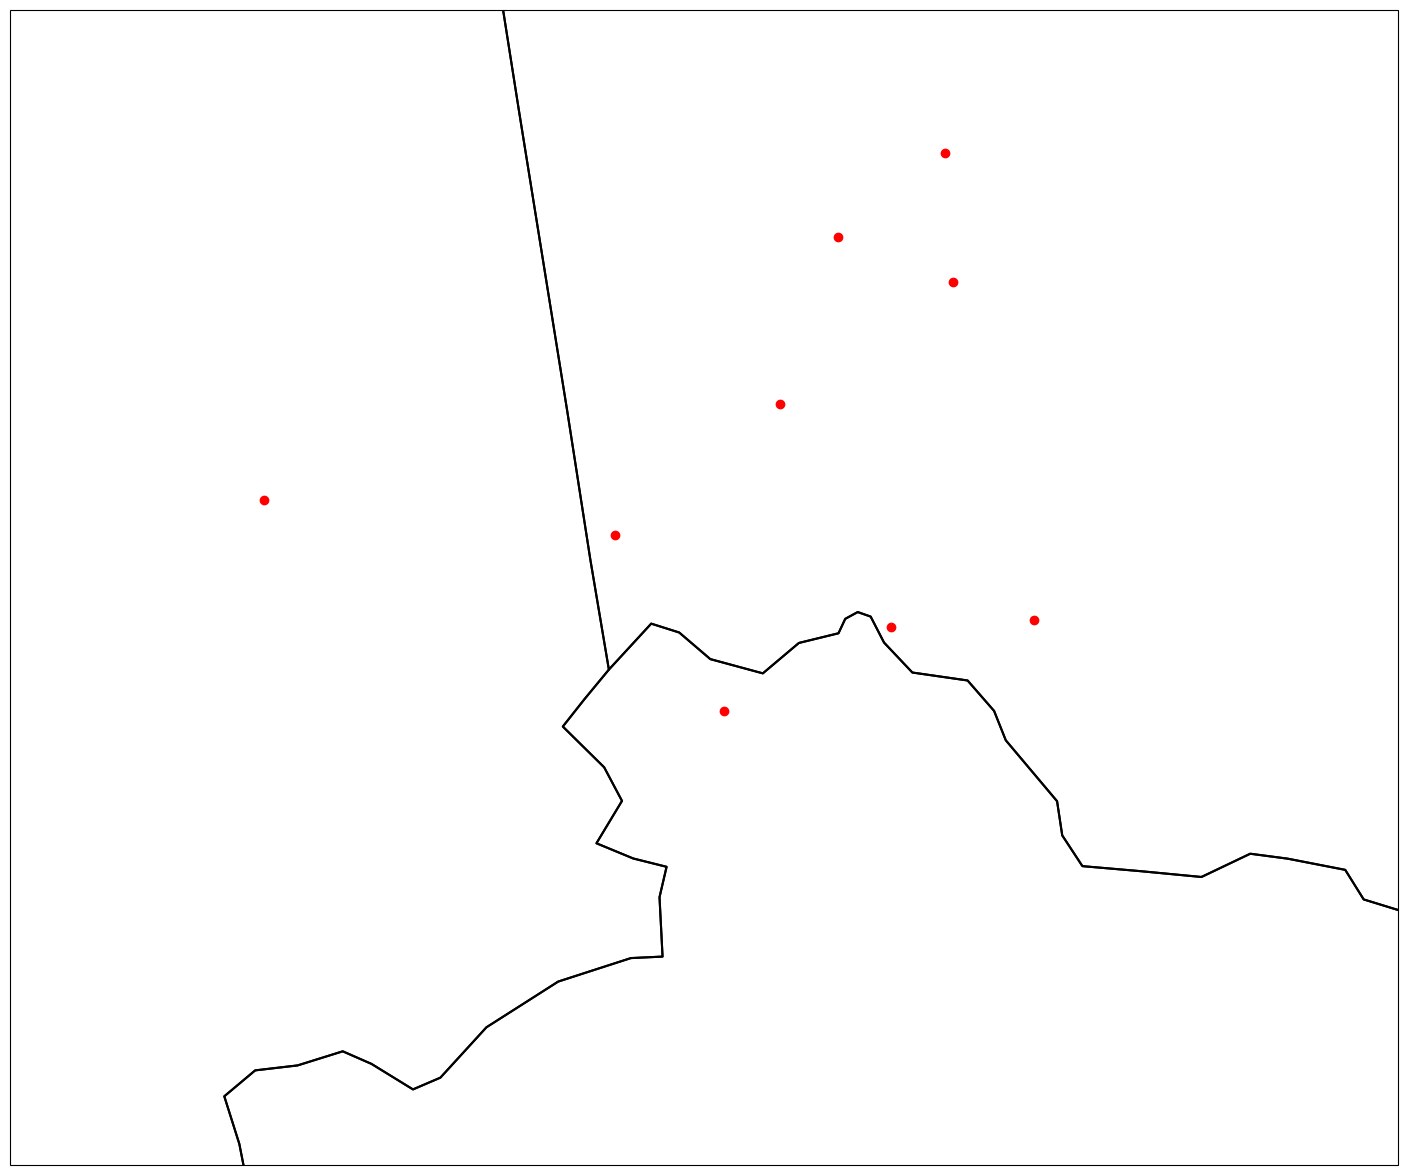

In [7]:
cenlon2 = cenlon1+0.2
cenlat2 = cenlat1+1.5

LL2 = (cenlon2-1.75,cenlat2+0.0,ccrs.PlateCarree())
UR2 = (cenlon2+0.,cenlat2+1.05,ccrs.PlateCarree())

# LL2 = (cenlon2-5,cenlat2+4,ccrs.PlateCarree())
# UR2 = (cenlon2+5.,cenlat2-4,ccrs.PlateCarree())

figure_mosaic = """
D
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(30,15), subplot_kw={'projection': crs})
prslev = [0,0.25,0.5,1.0,2.0,3.0,6.0]
#axes['D'].coastlines('50m',edgecolor='white',linewidth=0.75)
axes['D'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])
axes['D'].add_feature(states,edgecolor='k',linewidth=1.5,zorder=4)
#cf = axes['D'].pcolormesh(lon[0,:,:], lat[0,:,:], T2F[0,:,:], cmap=plt.cm.Greys, vmin=50, vmax=65, transform=ccrs.PlateCarree())
cm=axes['D'].scatter(prof_lons, prof_lats, c='r', transform=ccrs.PlateCarree())
#axes['D'].scatter(lon[0,691,706], lat[0,691,706], c='cyan', transform=ccrs.PlateCarree())


In [8]:
#Make arrays of heights and times
#For 1 km profile at a 3 m/s ascent/descent rate

#profile depth, in m
depth = 1000

#profile resolution, in m
res = 100

uas_z = np.concatenate([np.arange(res, depth+res, res), np.arange(depth-res, 0, res*-1)])


#Get time, in seconds, for this profile

#ascent rate (in m/s)
ar = 3

uas_time = np.arange(res/ar, ((len(uas_z)*res)/ar)+(res/ar), res/ar) 
print(uas_z)
print(uas_time)

print(uas_z.shape)
print(uas_time.shape)

[ 100  200  300  400  500  600  700  800  900 1000  900  800  700  600
  500  400  300  200  100]
[ 33.33333333  66.66666667 100.         133.33333333 166.66666667
 200.         233.33333333 266.66666667 300.         333.33333333
 366.66666667 400.         433.33333333 466.66666667 500.
 533.33333333 566.66666667 600.         633.33333333]
(19,)
(19,)


In [9]:
#Get interpolated obs from the profile
#First, read wrf file
mins=200
dt_start = datetime(2022,9,15,0,0)
dt = dt_start + timedelta(minutes=int(mins))
print(dt)
wrfout = Dataset('/glade/derecho/scratch/mawilson/20210604_newcase/nature_100IOP6/mem8_ens1/wrfout_d02_2022-'+str(dt.isoformat()[5:7])+'-'+str(dt.isoformat()[8:10])+'_'+str(dt.isoformat()[11:13])+':'+str(dt.isoformat()[14:16])+':00')
lon = wrfout.variables['XLONG']
lat = wrfout.variables['XLAT']
U10 = wrfout.variables['U10']
V10 = wrfout.variables['U10']
T2 = np.asarray(wrfout.variables['T2'])*units('K')
T2F = T2 .to('degF')
Q2 = np.asarray(wrfout.variables['Q2'])
P2 = np.asarray(wrfout.variables['PSFC'][:]/100) * units('hPa')
Td2 = dewpoint_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
RH2 = relative_humidity_from_specific_humidity(P2[0,:,:], T2[0,:,:], Q2[0,:,:]*units('kg/kg'))
SPD10 = wind_speed(np.asarray(U10)*units('m/s'), np.asarray(V10)*units('m/s'))
cloud=wrfout.variables['QCLOUD']
T_z = np.asarray(getvar(wrfout, "tk"))
p_z = np.asarray(getvar(wrfout, "pres"))
q_zi = np.asarray(wrfout.variables['QVAPOR'][:])
q_z = specific_humidity_from_mixing_ratio(q_zi)
u_z, v_z = getvar(wrfout, 'uvmet')
u_z = np.asarray(u_z)
v_z = np.asarray(v_z)
z_z = np.asarray(getvar(wrfout, "height_agl"))

2022-09-15 03:20:00


In [10]:
#Get the correct lat/lon for an example point
latp=prof_lats[0]
lonp=prof_lats[0]
#Get location for each ob in model land
lon1d = np.ndarray.flatten(lon[0,:,:])
lat1d = np.ndarray.flatten(lat[0,:,:])
station = []
points = []
for i in range(len(lon1d)):
    points.append((lat1d[i],lon1d[i]))
    station.append((latp,lonp))
dist = haversine.haversine_vector(station,points)
dist2=dist.reshape(lon.shape[1],lon.shape[2])
print(lon[0,:,:][np.where(dist2==np.min(dist2))])
print(lat[0,:,:][np.where(dist2==np.min(dist2))])
print(np.where(dist2==np.min(dist2)))
st_xind = np.where(dist2==np.min(dist2))[0][0]
st_yind = np.where(dist2==np.min(dist2))[1][0]

[-83.82182]
[39.67003]
(array([1007]), array([1241]))


In [15]:
#Actually get those interpolated obs
uas_T = []
uas_q = []
uas_u = []
uas_v = []
z_point = z_z[:,st_xind,st_yind]
t_point = T_z[:,st_xind,st_yind]
q_point = q_z[0,:,st_xind,st_yind]
u_point = u_z[:,st_xind,st_yind]
v_point = v_z[:,st_xind,st_yind]
for point in uas_z:
    T2_a = interpolate_1d(point, z_point, t_point)
    error = np.random.normal(loc=0.0, scale=np.sqrt(0.25))
    if np.abs(error) > 0.5:
        error = 0.5
    T2_b = T2_a + error
    uas_T.append(T2_b)
    
    q2_a = interpolate_1d(point, z_point, q_point)
    error = np.random.normal(loc=0.0, scale=np.sqrt(0.0025))
    if np.abs(error) > 0.005:
        error = 0.005
    q2_b = q2_a + error
    uas_q.append(q2_b)

    u2_a = interpolate_1d(point, z_point, u_point)
    error = np.random.normal(loc=0.0, scale=np.sqrt(0.25))
    if np.abs(error) > 0.5:
        error = 0.5
    u2_b = u2_a + error
    uas_u.append(u2_b)

    v2_a = interpolate_1d(point, z_point, v_point)
    error = np.random.normal(loc=0.0, scale=np.sqrt(0.25))
    if np.abs(error) > 0.5:
        error = 0.5
    v2_b = v2_a + error
    uas_v.append(v2_b)

In [16]:
print(T2_a)
print(z_point)
print(uas_z)

[294.00117752]
[1.6054535e+01 4.8388336e+01 8.1320282e+01 1.1523224e+02 1.5072946e+02
 1.8860526e+02 2.2971552e+02 2.7485950e+02 3.2476685e+02 3.8022046e+02
 4.4197772e+02 5.1081342e+02 5.8753339e+02 6.7301208e+02 7.6833777e+02
 8.7458594e+02 9.9300867e+02 1.1251578e+03 1.2725146e+03 1.4367904e+03
 1.6199169e+03 1.8238574e+03 2.0507095e+03 2.3027380e+03 2.5825989e+03
 2.8934680e+03 3.2392913e+03 3.6245437e+03 4.0538567e+03 4.5317725e+03
 5.0628066e+03 5.6521455e+03 6.3058164e+03 7.0297119e+03 7.8298867e+03
 8.7111689e+03 9.6774629e+03 1.0731783e+04 1.1887233e+04 1.3156389e+04
 1.4534034e+04 1.6022859e+04 1.7666277e+04 1.9541604e+04]
[ 100  200  300  400  500  600  700  800  900 1000  900  800  700  600
  500  400  300  200  100]


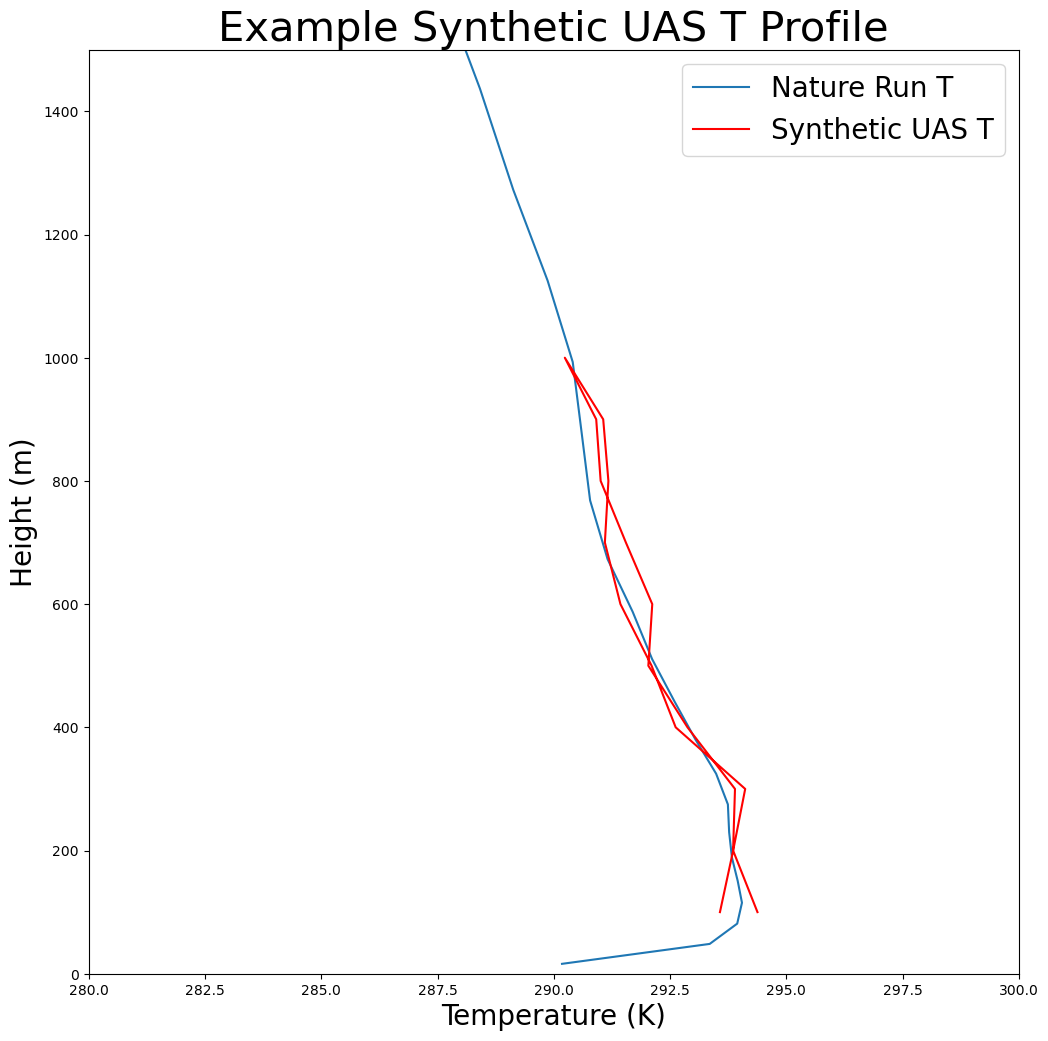

In [24]:
fig = plt.figure(1, figsize=(12,12))
plt.plot(t_point, z_point, label = 'Nature Run T')
#plt.plot(uas_Ti, uas_z, c='g')
plt.plot(uas_T, uas_z, c='r', label='Synthetic UAS T')
plt.ylim(0,1500)
plt.xlim(280, 300)
plt.title('Example Synthetic UAS T Profile', size=30)
plt.legend(fontsize=20)
plt.xlabel('Temperature (K)', size=20)
plt.ylabel('Height (m)', size=20)
plt.savefig('ExampleUASProfile.png', bbox_inches='tight')

(0.0, 2500.0)

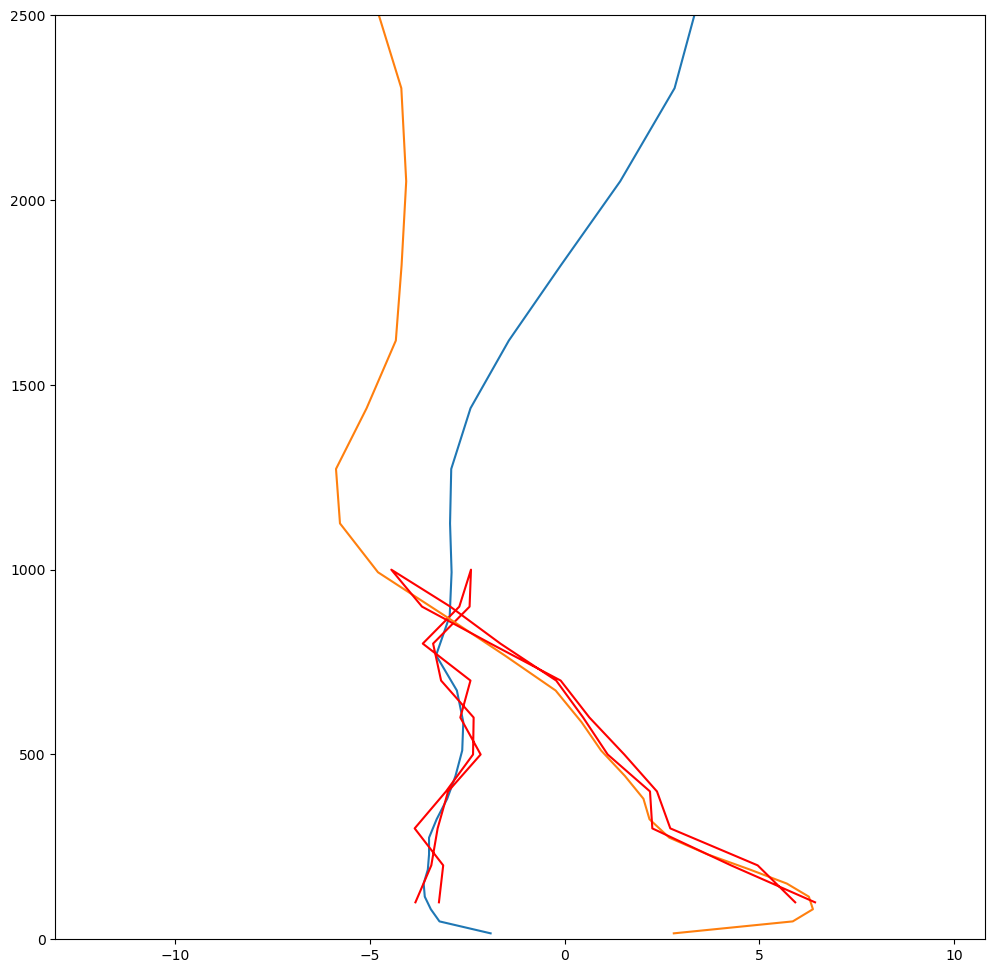

In [18]:
fig = plt.figure(1, figsize=(12,12))
plt.plot(u_point, z_point)
plt.plot(uas_u, uas_z, c='r')
plt.plot(v_point, z_point)
plt.plot(uas_v, uas_z, c='r')
plt.ylim(0,2500)
# plt.xlim(280, 300)